## Importing libraries

In [1]:
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization, Input
from keras.utils import image_dataset_from_directory
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import cv2

## Importing image data

In [7]:
import requests
import zipfile
import os

# url = "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1"

zip_path = "/content/drive/MyDrive/EuroSAT_RGB.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print(f"Extracted dataset to {extract_path}")

Extracted dataset to /content/


In [8]:
import shutil


In [10]:
classes = os.listdir("./EuroSAT_RGB/") # listing all classes
classes

['Residential',
 'HerbaceousVegetation',
 'AnnualCrop',
 'Highway',
 'Industrial',
 'PermanentCrop',
 'SeaLake',
 'Pasture',
 'Forest',
 'River']

In [11]:
# creating train and test folders
for cls in classes:
    os.makedirs(f"/content/train/{cls}")
    os.makedirs(f"/content/test/{cls}")

In [84]:
for cls in classes:
  print(cls, len(os.listdir(f"./EuroSAT_RGB/{cls}"))) #getting number of images per classes

Residential 3000
HerbaceousVegetation 3000
AnnualCrop 3000
Highway 2500
Industrial 2500
PermanentCrop 2500
SeaLake 3000
Pasture 2000
Forest 3000
River 2500


### Without Data Augmentation

## Train test split

In [14]:
# as the Pasture folder contains only 2000 images, balacing the train and test across all classes
# Im taking onlyfirst 2000 images per classes to make the data balanced.
for i in classes:
    train = os.listdir(f"./EuroSAT_RGB/{i}")[:1600]
    test = os.listdir(f"./EuroSAT_RGB/{i}")[1600:2000]

    for img in train:
        shutil.copyfile(os.path.join(f"./EuroSAT_RGB/{i}", img), os.path.join("train", i, img))
    for img in test:
        shutil.copyfile(os.path.join(f"./EuroSAT_RGB/{i}", img), os.path.join("test", i, img))

print("Dataset split complete")

Dataset split complete


In [15]:
# generators, divide batches of images, process large amount of data
# loading image data in batches
train_ds = image_dataset_from_directory(
    directory = '/content/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size=(64,64)
)

validation_ds = image_dataset_from_directory(
    directory = '/content/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size=(64,64)
)

Found 16000 files belonging to 10 classes.
Found 4000 files belonging to 10 classes.


In [16]:
labels = train_ds.class_names
labels

['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake']

In [18]:
#normalizing the image numpy array

def process(image, label):
    image = tf.cast(image/255. , tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [39]:
model = Sequential()

model.add(Input(shape=(64,64,3)))

model.add(Conv2D(32, (3,3), activation='relu'))
# model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
# model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
# model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(10, activation='softmax'))

In [40]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])

In [42]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("eurosat.keras", save_best_only=True)
]

In [43]:
history = model.fit(train_ds, validation_data=validation_ds, epochs=30, callbacks=[callbacks])

Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.3092 - loss: 1.7677 - val_accuracy: 0.5617 - val_loss: 1.1800
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5654 - loss: 1.1585 - val_accuracy: 0.6898 - val_loss: 0.9069
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6658 - loss: 0.9311 - val_accuracy: 0.6910 - val_loss: 0.8794
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7117 - loss: 0.8074 - val_accuracy: 0.7415 - val_loss: 0.7291
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7332 - loss: 0.7293 - val_accuracy: 0.7692 - val_loss: 0.6635
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7611 - loss: 0.6800 - val_accuracy: 0.7045 - val_loss: 0.8633
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7756 - loss: 0.6276 - val_accuracy: 0.7690 - val_loss: 0.6577
Epoch 8/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7872 - loss: 0.5822 - val_accuracy:

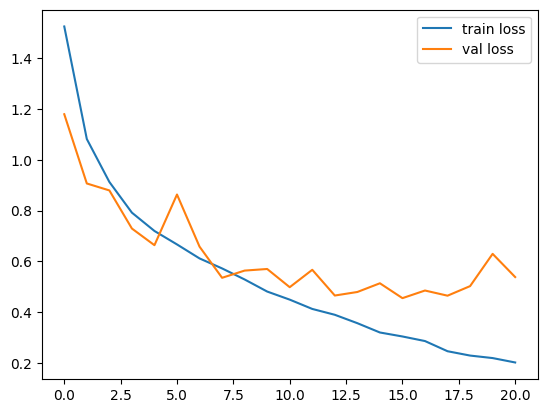

In [44]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

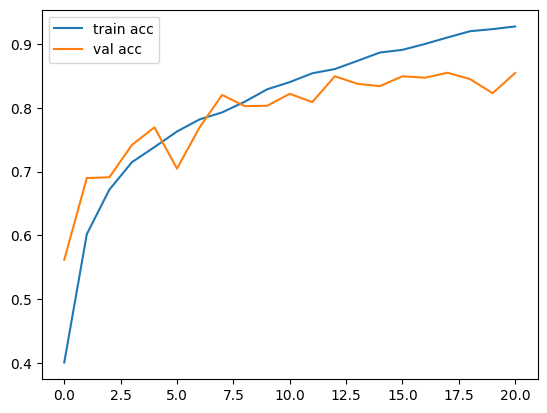

In [45]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [66]:
image = cv2.imread("/content/EuroSAT_RGB/AnnualCrop/AnnualCrop_1897.jpg") # read image for testing
# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (64,64)) # resize the image

In [67]:
test_input = image/255 #normalize the image
test_input = test_input.reshape(1, 64, 64, 3) # again reshape, as it is only a image not batch
print(test_input.shape)

(1, 64, 64, 3)


In [68]:
labels[np.argmax(model.predict(test_input))] #predict

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


'AnnualCrop'

In [87]:
labels = ['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake']

In [89]:
# using unseen image to evaluate the model

for i, folder in enumerate(labels):
  if folder != "Pasture":
    images = os.listdir(f"./EuroSAT_RGB/{folder}")[2000:] #listing all images after index 2000
    file_paths = [f"./EuroSAT_RGB/{folder}/{f}" for f in images]
    label = [i] * len(file_paths) # label for each classes
    class_data = tf.data.Dataset.from_tensor_slices((file_paths, label)) # it creates dataset pairs

    class_ds = class_data.map(lambda x, y: (tf.image.decode_jpeg(tf.io.read_file(x)), y)) # reading and decoding image data into tensor
    class_ds = class_ds.map(lambda x, y: (tf.image.resize(x, [64,64]) / 255., y)) # resizing and normalizing images
    class_ds = class_ds.batch(32).prefetch(tf.data.AUTOTUNE) #converting into batches

    # Evaluate
    print("model evaluation of class:", folder)
    model.evaluate(class_ds)
  else:
    print("Pasture has only 2000 images")

model evaluation of class: AnnualCrop
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7979 - loss: 0.6667
model evaluation of class: Forest
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9337 - loss: 0.1581
model evaluation of class: HerbaceousVegetation
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7300 - loss: 0.7229
model evaluation of class: Highway
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7615 - loss: 0.7266
model evaluation of class: Industrial
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9108 - loss: 0.2416
Pasture has only 2000 images
model evaluation of class: PermanentCrop
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7827 - loss: 0.6816
model evaluation of class: Residential
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9737 - loss: 0.1501
model evaluation of class: River
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6877 - loss: 0.8150
model evaluation of class: SeaLake
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc

## Conclusion

The custom CNN trained model shows good performance on the EuroSAT_RGB multiclass dataset consisting of 10 land cover classes, with the following best metrics achieved at epoch 18.
- Best metrics:
  - train_accuracy: 0.9081
  - train_loss: 0.2549
  - val_accuracy: 0.8547
  - val_loss: 0.4643

- strengths:
  - The model shows good generalization across most of the land cover classes.
  - The model is evaluated with both test/validation data and unseen images indicating reasonable robustness.
  - The architecture is compact and efficient, with approximately 680k+ parameters.
- Challenges:
  - the model exhibits class confusion among Vegetation related categories, such as AnnualCrop, HerbaceousVegetation, and River likely due to their visual similarity.
  - The observed gap between training and validation accuracy suggests mild overfitting, which can be improved by regularization or augmentation.